# Supplementary Analysis to better understand RQ2 Effects

Three models:

1. Plot of residuals from `E1 ~ Learning Session Count` grouped by control versus treatment
2. Plot of residuals from `E1 ~ Task Completion Session Count` grouped by control versus treatment
3. Plot of residuals from `E1 ~ Learning Session Count + Task Completion Session Count` grouped by control versus treatment

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TABLEAU_COLORS

import seaborn as sns
from scipy import stats
import json
import import_ipynb
from IPython.display import display, HTML
# from analysis_with_ai import invoke_openrouter_ai, INTERACTION_PROMPT_TEMPLATEv2, classify_interaction
# from helper_functions import independent_ttest
from helper_functions import linear_regression_analysis, linear_regression_assumption_checks

In [5]:
# Read in the final data set
dataset = pd.read_csv("../datasets/dps-thesis-dataset.csv")
dataset.columns

Index(['participant_number', 'survey_done', 'chatbot_done', 'chatbot_group',
       'first_year', 'gender', 'year_in_school_simplified',
       'first_prog_course', 'C1', 'C2', 'E1', 'Difference_C2_C1',
       'inconclusive_session_count', 'learning_session_count',
       'task_completion_session_count', 'total_session_count',
       'total_interaction_count', 'interaction_to_session_ratio',
       'control_treatment_asnumber', 'first_prog_course_asnumber',
       'gender_asnumber', 'year_in_school_simplified_asnumber'],
      dtype='object')

### Residuals Learning Session Count vs E1

Grouped by control versus treatment.


Fitting model with standard OLS...


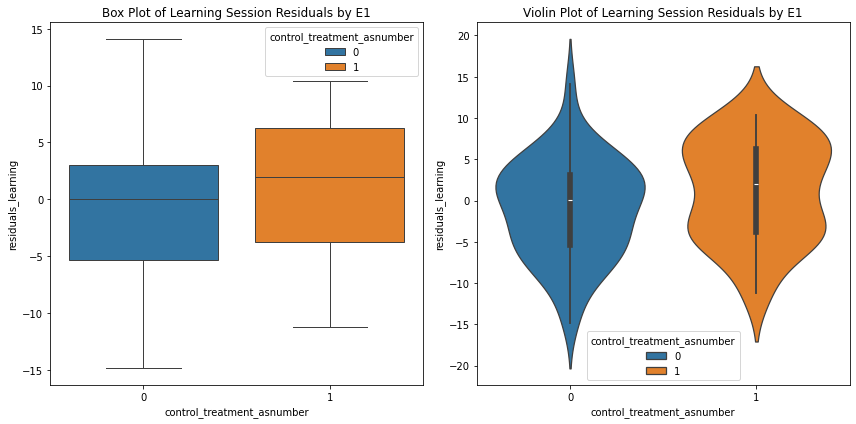

,count,mean,std,min,25%,50%,75%,max
control_treatment_asnumber,,,,,,,,
0,48.0,-0.971934,5.936866,-14.857902,-5.359269,0.010685,3.058939,14.107194
1,39.0,1.196226,6.096478,-11.214505,-3.764126,1.978515,6.300214,10.399457


Levene's test for homogeneity of variance: stat=0.4273405863145381, p=0.51506139396695


In [6]:
ind_vars = ['learning_session_count']
dep_var = "E1"

model = linear_regression_analysis(dataset, ind_vars, dep_var, do_print=False, do_plot=False, robust_std_errors=False)

# Save residuals from the regression
residuals = model.resid
# Add residuals to dataset for plotting
dataset['residuals_learning'] = residuals
# show side by size box plots and violin plots of residuals by control vs treatment
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='control_treatment_asnumber', y='residuals_learning', data=dataset, hue='control_treatment_asnumber', palette=list(TABLEAU_COLORS.values()))
plt.title('Box Plot of Learning Session Residuals by E1')
plt.subplot(1, 2, 2)
sns.violinplot(x='control_treatment_asnumber', y='residuals_learning', data=dataset, hue='control_treatment_asnumber', palette=list(TABLEAU_COLORS.values()))
plt.title('Violin Plot of Learning Session Residuals by E1')
plt.tight_layout()
plt.show()

# Descriptive statistics for residuals by control vs treatment
desc_stats = dataset.groupby('control_treatment_asnumber')['residuals_learning'].describe()
display(desc_stats)

# perform a levene's test for homogeneity of variance
levene_stat, levene_p = stats.levene(
    dataset[dataset['control_treatment_asnumber'] == 0]['residuals_learning'],
    dataset[dataset['control_treatment_asnumber'] == 1]['residuals_learning']
)
print(f"Levene's test for homogeneity of variance: stat={levene_stat}, p={levene_p}")

### Residuals Task Completion Session Count vs E1

grouped by control versus treatment.



Fitting model with standard OLS...


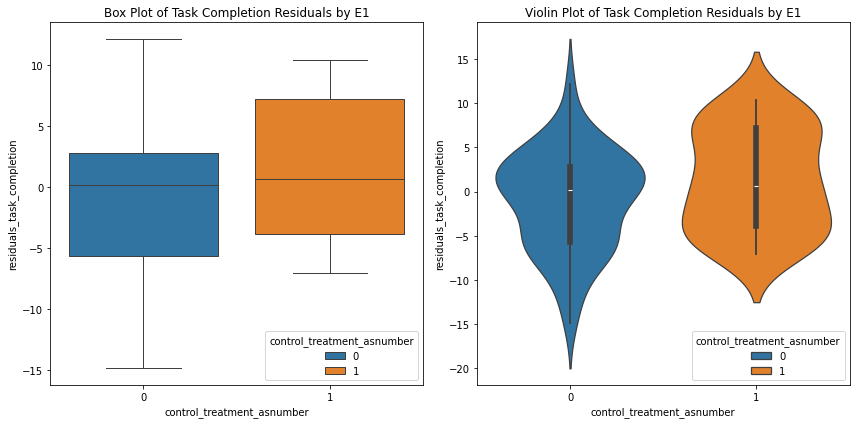

,count,mean,std,min,25%,50%,75%,max
control_treatment_asnumber,,,,,,,,
0,48.0,-1.007979,5.574422,-14.866952,-5.685634,0.133048,2.806124,12.133048
1,39.0,1.240589,5.662842,-7.072084,-3.883437,0.616563,7.186159,10.374806


Levene's test for homogeneity of variance: stat=0.403030876238569, p=0.5272332993270928


In [7]:
ind_vars = ['task_completion_session_count']
dep_var = "E1"

model = linear_regression_analysis(dataset, ind_vars, dep_var, do_print=False, do_plot=False, robust_std_errors=False)

# Save residuals from the regression
residuals = model.resid
# Add residuals to dataset for plotting
dataset['residuals_task_completion'] = residuals
# show side by size box plots and violin plots of residuals by control vs treatment
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='control_treatment_asnumber', y='residuals_task_completion', data=dataset, hue='control_treatment_asnumber', palette=list(TABLEAU_COLORS.values()))
plt.title('Box Plot of Task Completion Residuals by E1')
plt.subplot(1, 2, 2)
sns.violinplot(x='control_treatment_asnumber', y='residuals_task_completion', data=dataset, hue='control_treatment_asnumber', palette=list(TABLEAU_COLORS.values()))
plt.title('Violin Plot of Task Completion Residuals by E1')
plt.tight_layout()
plt.show()

# Descriptive statistics for residuals by control vs treatment
desc_stats = dataset.groupby('control_treatment_asnumber')['residuals_task_completion'].describe()
display(desc_stats)

# perform a levene's test for homogeneity of variance
levene_stat, levene_p = stats.levene(
    dataset[dataset['control_treatment_asnumber'] == 0]['residuals_task_completion'],
    dataset[dataset['control_treatment_asnumber'] == 1]['residuals_task_completion']
)
print(f"Levene's test for homogeneity of variance: stat={levene_stat}, p={levene_p}")

## Residuals of both IV's on E1

broken down by control vs treatment


Fitting model with standard OLS...


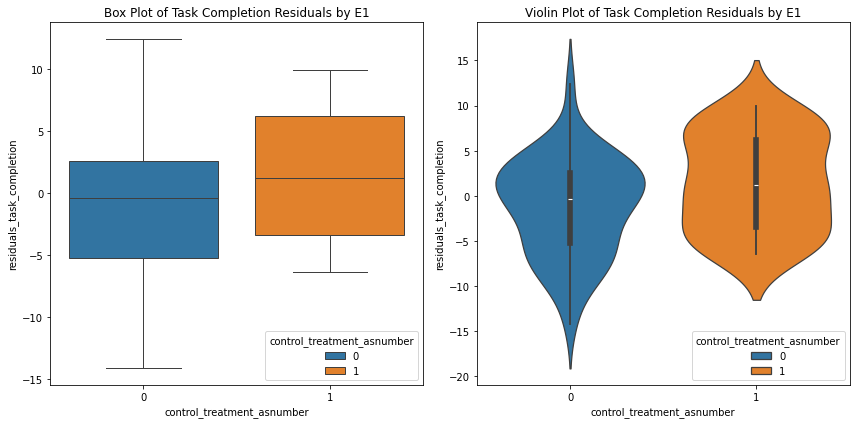

,count,mean,std,min,25%,50%,75%,max
control_treatment_asnumber,,,,,,,,
0,48.0,-1.199913,5.382352,-14.159344,-5.255646,-0.389248,2.563666,12.429346
1,39.0,1.476816,5.318900,-6.407109,-3.424441,1.223691,6.174777,9.928259


In [8]:
ind_vars = ['learning_session_count', 'task_completion_session_count']
dep_var = "E1"

model = linear_regression_analysis(dataset, ind_vars, dep_var, do_print=False, do_plot=False, robust_std_errors=False)

# Save residuals from the regression
residuals = model.resid
# Add residuals to dataset for plotting
dataset['residuals_task_completion'] = residuals
# show side by size box plots and violin plots of residuals by control vs treatment
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='control_treatment_asnumber', y='residuals_task_completion', data=dataset, hue='control_treatment_asnumber', palette=list(TABLEAU_COLORS.values()))
plt.title('Box Plot of Task Completion Residuals by E1')
plt.subplot(1, 2, 2)
sns.violinplot(x='control_treatment_asnumber', y='residuals_task_completion', data=dataset, hue='control_treatment_asnumber', palette=list(TABLEAU_COLORS.values()))
plt.title('Violin Plot of Task Completion Residuals by E1')
plt.tight_layout()
plt.show()

# Descriptive statistics for residuals by control vs treatment
desc_stats = dataset.groupby('control_treatment_asnumber')['residuals_task_completion'].describe()
display(desc_stats)


# Chi Square Analysis

To further investigate the effects observed in RQ2, we conducted a chi-square analysis to examine the relationship between categorical variables in our dataset and the multimodal distribution observed in the treatment. 

For this analysis we will only look at the treatment group since the control group did not exhibit a multimodal distribution. In addition we will filter on only participants who completed a survey.  
Finally, based on the median residual value from the treatment group, we will create a binary variable indicating whether a participant's residual is above or below the median.  

    UP = Under-Predicted (residual below median)
    OP = Over-Predicted (residual above median)




In [19]:

# only in the treatment group and only survey_done == 'Y' 
dataset2 = dataset[(dataset['control_treatment_asnumber'] == 1) & (dataset['survey_done'] == 'Y') & (dataset['gender_asnumber']<2.0)].copy()
l_resid =  dataset2['residuals_learning'].median()
tc_resid = dataset2['residuals_task_completion'].median()
dataset2['residuals_learning_code'] =dataset2['residuals_learning'].apply(lambda x: 'OP' if x > l_resid else 'UP')
dataset2['residuals_task_completion_code'] =dataset2['residuals_task_completion'].apply(lambda x: 'OP' if x > tc_resid else 'UP')



In [20]:
### Data Engineering



In [11]:
residual_cols = ['residuals_learning_code', 'residuals_task_completion_code']
demographic_cols = ['first_year', 'gender', 'first_prog_course']

for r in residual_cols:
    display(HTML(f"<h2>Analyzing Residuals: '{r}'</h2>"))
    for d in demographic_cols:
        display(HTML(f"<h3>with Demographic Variable: '{d}'</h3>"))
        ct = pd.crosstab(dataset2[r], dataset2[d])
        chi2, p, dof, ex = stats.chi2_contingency(ct)
        df = pd.DataFrame({ 'test' :[f"{r} and {d}"],
                            'chi2_statistic' : [chi2],
                            'p_value' : [p],
                            'degrees_of_freedom' : [dof],
                            'expected_frequencies' : [ex]})

        display(ct)
        display(df.T)


first_year,N,Y
residuals_learning_code,,
OP,2,15
UP,3,14


,0
test,residuals_learning_code and first_year
chi2_statistic,0.0
p_value,1.0
degrees_of_freedom,1
expected_frequencies,"[[2.5, 14.5], [2.5, 14.5]]"


gender,Female,Male
residuals_learning_code,,
OP,10,7
UP,2,15


,0
test,residuals_learning_code and gender
chi2_statistic,6.310606
p_value,0.012002
degrees_of_freedom,1
expected_frequencies,"[[6.0, 11.0], [6.0, 11.0]]"


first_prog_course,N,Y
residuals_learning_code,,
OP,7,10
UP,6,11


...

,0
test,residuals_task_completion_code and first_year
chi2_statistic,0.0
p_value,1.0
degrees_of_freedom,1
expected_frequencies,"[[2.5, 14.5], [2.5, 14.5]]"


gender,Female,Male
residuals_task_completion_code,,
OP,9,8
UP,3,14


,0
test,residuals_task_completion_code and gender
chi2_statistic,3.219697
p_value,0.072757
degrees_of_freedom,1
expected_frequencies,"[[6.0, 11.0], [6.0, 11.0]]"


first_prog_course,N,Y
residuals_task_completion_code,,
OP,8,9
UP,5,12


,0
test,residuals_task_completion_code and first_prog_...
chi2_statistic,0.498168
p_value,0.480306
degrees_of_freedom,1
expected_frequencies,"[[6.5, 10.5], [6.5, 10.5]]"


# Summary of Regression Models

E1 prediction models										

|Independent Variables|N|Deg. f|p-value|r-squared|Significant?|Power?|Const|B-treatment|B-gender|Notes|
|---------------------|--|-------|--------|----------|------------|------|-----|-----------|--------|-----|
|Control/Treatment|87|1|0.119|0.028|N|N|30.23|2.05|N/A|Not significant.|
|Treatment Only + Gender |34|1|0.000|0.198|Y|Y|36.00|N/A|-6.05|Controlling for Treatment = 1|
|Control/Treatment + Gender|77|2|0.022|0.098|Y|N|31.85|2.63|-3.07|Underpowered target r-squared 0.115|
|Control/Treatment + Learning + Task Completion|87|3|0.000|0.238|Y|Y|30.66|2.74|N/A|Original: Treatment only when controlling for Learning + Task Completion|
|Control/Treatment + Learning + Task Completion + Gender|77|4|0.000|0.293|Y|Y|32.37|3.22|-2.77|Original: Treatment only when controlling for Learning + Task Completion + Gender|


In [12]:
# Filtered on surveys 
dataset3 = dataset[(dataset['survey_done'] == 'Y') & (dataset['gender_asnumber']<2.0)].copy()


## Just Treatment Group

 Straight regression analysis on just the treatment group to see if the effects hold.


Fitting model with standard OLS...
********************************************************************************
INDEPENDENT VAR: ['control_treatment_asnumber']
DEPENDENT VAR  : E1
REGRESSORS     : 1
                            OLS Regression Results                            
Dep. Variable:                     E1   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     2.485
Date:                Mon, 17 Nov 2025   Prob (F-statistic):              0.119
Time:                        22:03:46   Log-Likelihood:                -278.92
No. Observations:                  87   AIC:                             561.8
Df Residuals:                      85   BIC:                             566.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
      

<Axes: xlabel='Coefficient', ylabel='Confidence intervals for dependent variable E1'>

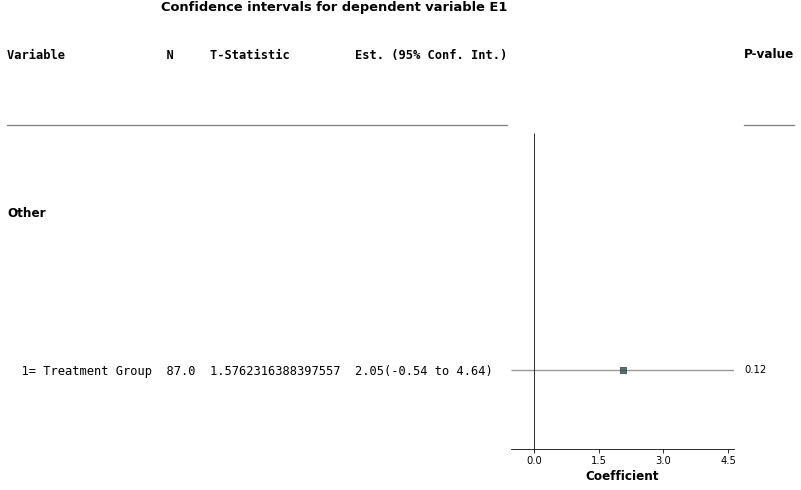

In [13]:
ind_vars = ['control_treatment_asnumber']
dep_var = "E1"

linear_regression_analysis(dataset, ind_vars, dep_var)

## Treatment only and Gender

- significant
- powered
- look at the beta: females -6.05 vs males


Fitting model with standard OLS...
********************************************************************************
INDEPENDENT VAR: ['gender_asnumber']
DEPENDENT VAR  : E1
REGRESSORS     : 1
                            OLS Regression Results                            
Dep. Variable:                     E1   R-squared:                       0.226
Model:                            OLS   Adj. R-squared:                  0.202
Method:                 Least Squares   F-statistic:                     9.366
Date:                Mon, 17 Nov 2025   Prob (F-statistic):            0.00445
Time:                        22:03:47   Log-Likelihood:                -105.24
No. Observations:                  34   AIC:                             214.5
Df Residuals:                      32   BIC:                             217.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 

<Axes: xlabel='Coefficient', ylabel='Confidence intervals for dependent variable E1'>

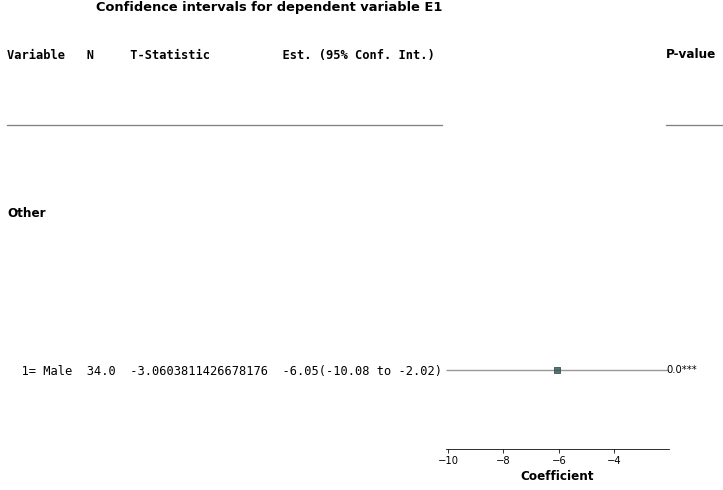

In [14]:
ind_vars = ['gender_asnumber']
dep_var = "E1"

linear_regression_analysis(dataset2, ind_vars, dep_var)

## Control / Treatment and Gender

- significant
- underpowered
- beta for females -3.06 vs males
- treatment beta is 2.63



Fitting model with standard OLS...
********************************************************************************
INDEPENDENT VAR: ['control_treatment_asnumber', 'gender_asnumber']
DEPENDENT VAR  : E1
REGRESSORS     : 2
                            OLS Regression Results                            
Dep. Variable:                     E1   R-squared:                       0.098
Model:                            OLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     4.023
Date:                Mon, 17 Nov 2025   Prob (F-statistic):             0.0220
Time:                        22:03:48   Log-Likelihood:                -244.20
No. Observations:                  77   AIC:                             494.4
Df Residuals:                      74   BIC:                             501.4
Df Model:                           2                                         
Covariance Type:            nonrobust                             

<Axes: xlabel='Coefficient', ylabel='Confidence intervals for dependent variable E1'>

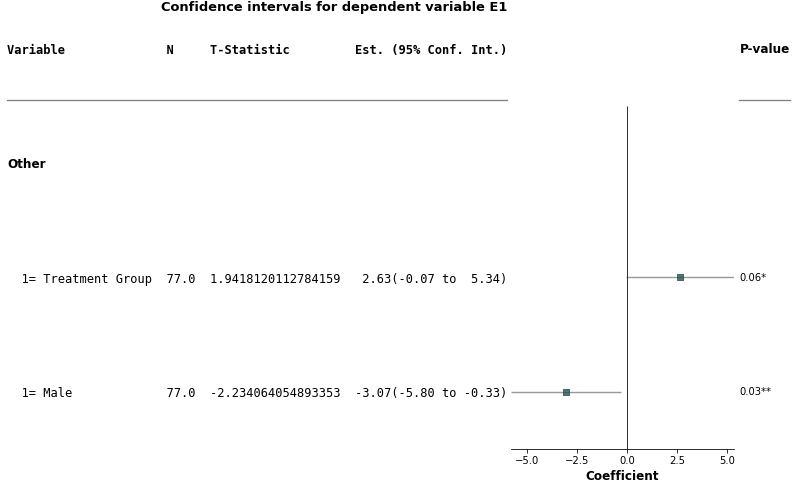

In [15]:
ind_vars = ['control_treatment_asnumber', 'gender_asnumber' ]
dep_var = "E1"

linear_regression_analysis(dataset3, ind_vars, dep_var)

## Original Regression

For old times sake, the original refgression model

- powered p < 0.05 
- significant r-squared 0.2380
- treatment 2.74 over control
- only applies to those with similar learning and task completion session counts


Fitting model with standard OLS...
********************************************************************************
INDEPENDENT VAR: ['control_treatment_asnumber', 'learning_session_count', 'task_completion_session_count']
DEPENDENT VAR  : E1
REGRESSORS     : 3
                            OLS Regression Results                            
Dep. Variable:                     E1   R-squared:                       0.238
Model:                            OLS   Adj. R-squared:                  0.210
Method:                 Least Squares   F-statistic:                     8.641
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           4.68e-05
Time:                        22:03:48   Log-Likelihood:                -268.35
No. Observations:                  87   AIC:                             544.7
Df Residuals:                      83   BIC:                             554.6
Df Model:                           3                                         
Covariance Type:          

<Axes: xlabel='Coefficient', ylabel='Confidence intervals for dependent variable E1'>

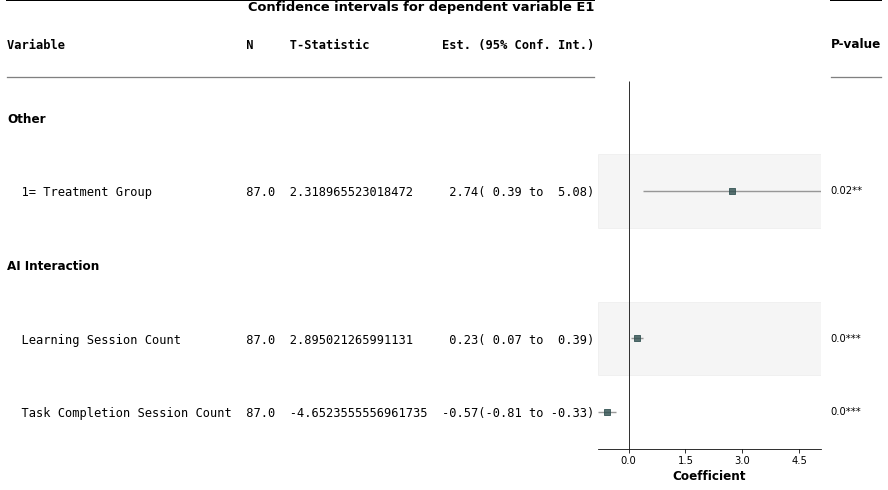

In [16]:
ind_vars = ['control_treatment_asnumber', 'learning_session_count', 'task_completion_session_count']
dep_var = "E1"

linear_regression_analysis(dataset, ind_vars, dep_var)

## Original Regression with Gender

- powered p < 0.05
- significant r-squared 0.2932
- treatment 3.22 over control
- females -2.77 vs males
- only applies to those with similar learning and task completion session counts


Fitting model with standard OLS...
********************************************************************************
INDEPENDENT VAR: ['control_treatment_asnumber', 'gender_asnumber', 'learning_session_count', 'task_completion_session_count']
DEPENDENT VAR  : E1
REGRESSORS     : 4
                            OLS Regression Results                            
Dep. Variable:                     E1   R-squared:                       0.293
Model:                            OLS   Adj. R-squared:                  0.254
Method:                 Least Squares   F-statistic:                     7.467
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           4.34e-05
Time:                        22:03:49   Log-Likelihood:                -234.82
No. Observations:                  77   AIC:                             479.6
Df Residuals:                      72   BIC:                             491.4
Df Model:                           4                                         
Covaria

<Axes: xlabel='Coefficient', ylabel='Confidence intervals for dependent variable E1'>

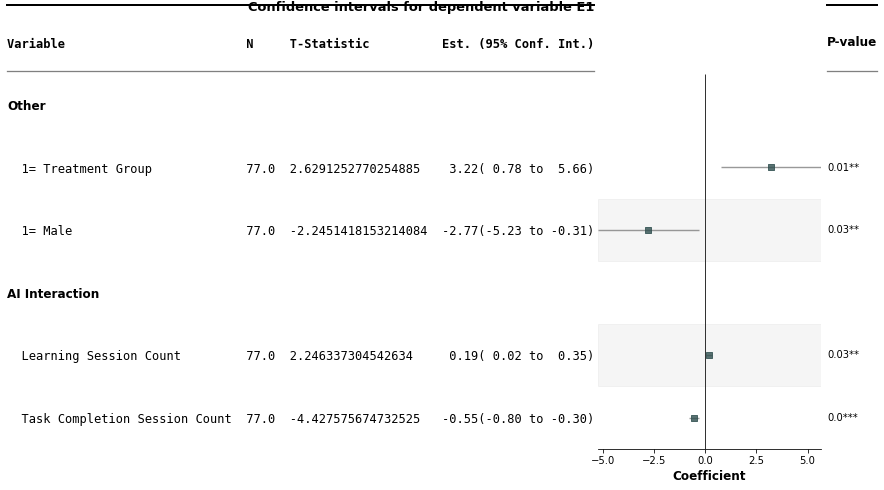

In [17]:
ind_vars = ['control_treatment_asnumber', 'gender_asnumber', 'learning_session_count', 'task_completion_session_count']
dep_var = "E1"

linear_regression_analysis(dataset3, ind_vars, dep_var)